In [44]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

def load_data():
    # Load data for three classes
    class1 = np.loadtxt('/home/user/SPR_assignment/Spr_assignment1/Assignment_1_dataset/Group03/LS_Group03/Class1.txt')
    class2 = np.loadtxt('/home/user/SPR_assignment/Spr_assignment1/Assignment_1_dataset/Group03/LS_Group03/Class2.txt')
    class3 = np.loadtxt('/home/user/SPR_assignment/Spr_assignment1/Assignment_1_dataset/Group03/LS_Group03/Class3.txt')
    
    
    # Combine data into a single array
    X = np.vstack((class1, class2, class3))
    y = np.array([0] * len(class1) + [1] * len(class2) + [2] * len(class3))  # Assign labels
    return X, y

def split_data(X, y, train_ratio=0.7):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    train_size = int(len(indices) * train_ratio)
    train_indices, test_indices = indices[:train_size], indices[train_size:]
    return X[train_indices], y[train_indices], X[test_indices], y[test_indices]


In [46]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        X_bias = np.hstack((np.ones((X.shape[0], 1)), X))  # Add bias term
        self.weights = np.zeros(X_bias.shape[1])
        for _ in range(self.epochs):
            predictions = self._sigmoid(X_bias @ self.weights)
            gradient = X_bias.T @ (predictions - y) / X.shape[0]
            self.weights -= self.learning_rate * gradient

    def predict(self, X):
        X_bias = np.hstack((np.ones((X.shape[0], 1)), X))  # Add bias term
        return (self._sigmoid(X_bias @ self.weights) >= 0.5).astype(int)

class LogisticRegressionOVR:
    def __init__(self, num_classes, learning_rate=0.01, epochs=1000):
        self.num_classes = num_classes
        self.models = [LogisticRegression(learning_rate, epochs) for _ in range(num_classes)]

    def fit(self, X, y):
        for i in range(self.num_classes):
            binary_y = (y == i).astype(int)
            self.models[i].fit(X, binary_y)

    def predict(self, X):
        X_bias = np.hstack((np.ones((X.shape[0], 1)), X))
        predictions = np.array([model._sigmoid(X_bias @ model.weights) for model in self.models]).T
        return np.argmax(predictions, axis=1)


In [48]:
def calculate_metrics(y_true, y_pred):
    classes = np.unique(y_true)
    metrics = {'accuracy': np.mean(y_pred == y_true),
               'precision': [], 'recall': [], 'f_measure': []}
    for cls in classes:
        true_pos = np.sum((y_pred == cls) & (y_true == cls))
        false_pos = np.sum((y_pred == cls) & (y_true != cls))
        false_neg = np.sum((y_pred != cls) & (y_true == cls))
        precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
        recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
        f_measure = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        metrics['precision'].append(precision)
        metrics['recall'].append(recall)
        metrics['f_measure'].append(f_measure)
    metrics['mean_precision'] = np.mean(metrics['precision'])
    metrics['mean_recall'] = np.mean(metrics['recall'])
    metrics['mean_f_measure'] = np.mean(metrics['f_measure'])
    return metrics


In [50]:
def plot_decision_regions(X, y, model, title="Decision Regions"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=20, cmap=plt.cm.RdYlBu)
    plt.title(title)
    plt.show()


In [52]:
def pairwise_classification(X_train, y_train, X_test, y_test, pairs):
    for pair in pairs:
        cls1, cls2 = pair
        pair_indices = np.where((y_train == cls1) | (y_train == cls2))
        X_pair, y_pair = X_train[pair_indices], y_train[pair_indices]
        y_pair_binary = (y_pair == cls1).astype(int)

        model_pair = LogisticRegression(learning_rate=0.1, epochs=2000)
        model_pair.fit(X_pair, y_pair_binary)

        pair_test_indices = np.where((y_test == cls1) | (y_test == cls2))
        X_test_pair, y_test_pair = X_test[pair_test_indices], y_test[pair_test_indices]
        y_test_pair_binary = (y_test_pair == cls1).astype(int)

        y_pred_pair = model_pair.predict(X_test_pair)
        metrics = calculate_metrics(y_test_pair_binary, y_pred_pair)
        print(f"Metrics for pair {cls1} vs {cls2}:", metrics)

        # Generate and display confusion matrix
        cm = confusion_matrix(y_test_pair_binary, y_pred_pair)
        print(f"Confusion Matrix for pair {cls1} vs {cls2}:\n", cm)

        # Plot decision regions
        plot_decision_regions(X_test_pair, y_test_pair_binary, model_pair, title=f"Decision Region: Class {cls1} vs Class {cls2}")


Metrics for all classes: {'accuracy': 1.0, 'precision': [1.0, 1.0, 1.0], 'recall': [1.0, 1.0, 1.0], 'f_measure': [1.0, 1.0, 1.0], 'mean_precision': 1.0, 'mean_recall': 1.0, 'mean_f_measure': 1.0}
Confusion Matrix (All Classes):
 [[157   0   0]
 [  0 153   0]
 [  0   0 140]]


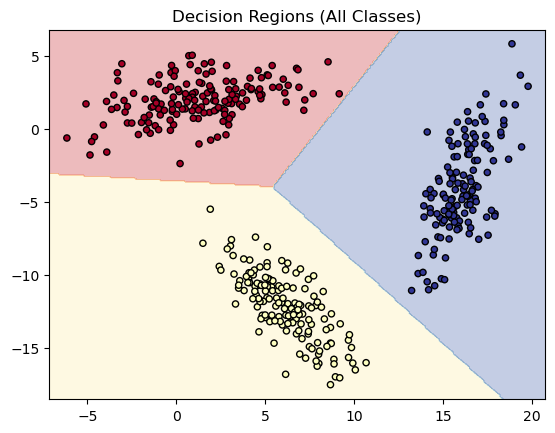

Metrics for pair 1 vs 2: {'accuracy': 1.0, 'precision': [1.0, 1.0], 'recall': [1.0, 1.0], 'f_measure': [1.0, 1.0], 'mean_precision': 1.0, 'mean_recall': 1.0, 'mean_f_measure': 1.0}
Confusion Matrix for pair 1 vs 2:
 [[140   0]
 [  0 153]]


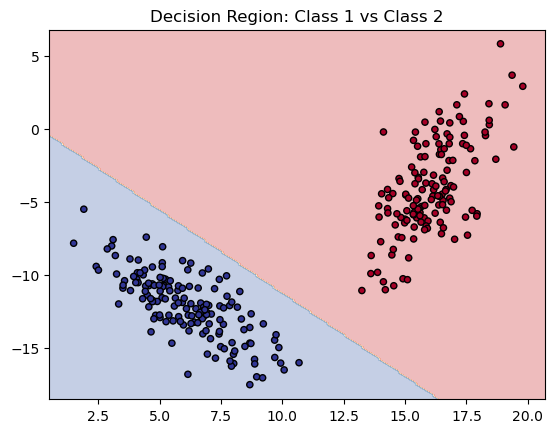

Metrics for pair 2 vs 0: {'accuracy': 1.0, 'precision': [1.0, 1.0], 'recall': [1.0, 1.0], 'f_measure': [1.0, 1.0], 'mean_precision': 1.0, 'mean_recall': 1.0, 'mean_f_measure': 1.0}
Confusion Matrix for pair 2 vs 0:
 [[157   0]
 [  0 140]]


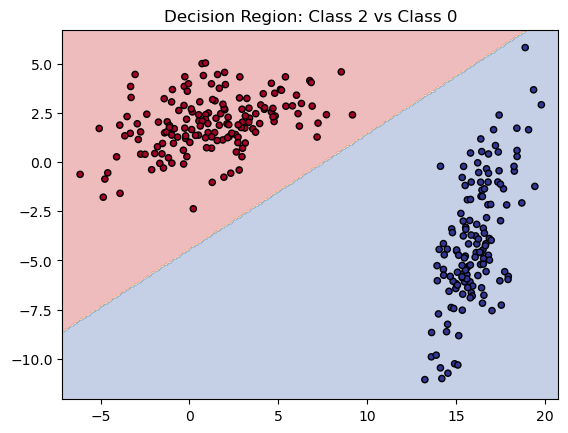

Metrics for pair 0 vs 1: {'accuracy': 1.0, 'precision': [1.0, 1.0], 'recall': [1.0, 1.0], 'f_measure': [1.0, 1.0], 'mean_precision': 1.0, 'mean_recall': 1.0, 'mean_f_measure': 1.0}
Confusion Matrix for pair 0 vs 1:
 [[153   0]
 [  0 157]]


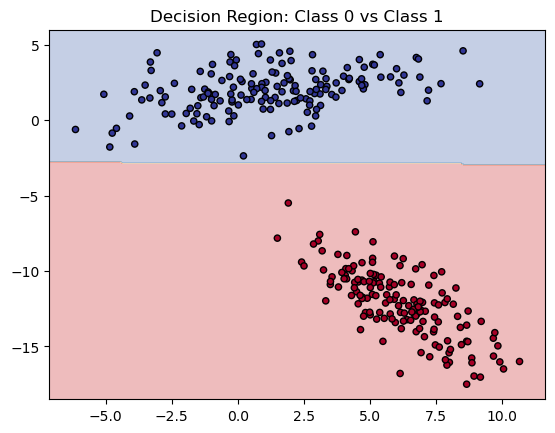

In [54]:
if __name__ == "__main__":
    # Load and split data
    X, y = load_data()
    X_train, y_train, X_test, y_test = split_data(X, y)

    # Train model for all classes
    model = LogisticRegressionOVR(num_classes=3, learning_rate=0.1, epochs=2000)
    model.fit(X_train, y_train)

    # Evaluate metrics for full classification
    y_pred = model.predict(X_test)
    full_metrics = calculate_metrics(y_test, y_pred)
    print("Metrics for all classes:", full_metrics)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix (All Classes):\n", cm)

    # Decision region plot for all classes
    plot_decision_regions(X_test, y_test, model, title="Decision Regions (All Classes)")

    # Pairwise classification
    pairs = [(1, 2), (2, 0), (0, 1)]
    pairwise_classification(X_train, y_train, X_test, y_test, pairs)
